# Trimer Case 2: QME

## Quantum Master equation



We assume that the dipole moment is perpendicular to the plane and thus $\mathbf{d}\cdot\mathbf{r}_{ij}=0$  for all edges of the triangle. Hence, the off-diagonal $\Gamma_{ij}$ and the dipole-dipole interaction are

$$
\Gamma_{12}=\Gamma_{23}=\Gamma_{31}= \frac{3}{2}\gamma_{0} \left[ \frac{\sin\xi}{\xi}\left(1 - \frac{1}{\xi^2}\right) + \frac{\cos\xi}{\xi^2} \right]
$$(eq:Gamma_ij-S3

and

$$
\Omega_{12} = \Omega_{23} = \Omega_{31} = - \frac{3}{4} \gamma_0 \left[\frac{\cos\xi}{\xi} \left(1-\frac{1}{\xi^2} \right) - \frac{\sin\xi}{\xi^2} \right]
$$(eq:Omega_ij_S3)

where $\xi = k_{0} r_{12}$.  To prevent exceedingly large dipole-dipole coupling, we set a cut off distance at $r_{c} = 0$ so that $\Omega_{ij} (r_{ij}<r_{c}) = \Omega_{ij}(r_{c}$.


The Hamiltonian of the system is given by 

$$
H = \frac{\omega}{2} \sum_{i=1}^{3} \sigma^{z}_{i} + \sum_{i\ne j} \Omega_{ij} \sigma^{+}_{i}\sigma^{-}_{j}
$$

and the dissipator in the diagonal form by

$$
\mathcal{D} (\rho) = \sum_{j=1}^{3} \gamma_{i} (N_{T}+1)  \left (L_{j} \rho L^{\dagger}_{j} - \frac{1}{2} \left\{L^{\dagger}_{j} L_{j},\rho\right\} \right)
+ \sum_{j=1}^{3} \gamma_{i} N_{T} \left (L^{\dagger}_{j} \rho L_{j} - \frac{1}{2} \left\{L_{j} L^{\dagger}_{j},\rho\right\} \right)
$$

where the decay rates for the three channels are

$$
\gamma_{1} = \Gamma_{11} + 2 \Gamma_{12}, \qquad \gamma_{2} = \gamma_{3} = \Gamma_{11}-\Gamma_{12}
$$

and the jump operators are

$$
L_{1} = \frac{1}{\sqrt{3}} \left(\sigma^{-}_{1} + \sigma^{-}_{2} + \sigma^{-}_{3} \right)  \\
L_{2} = \frac{1}{\sqrt{3}} \left(e^{-i 2\pi/3} \sigma^{-}_{1} + e^{i 2\pi/3}\sigma^{-}_{2} + \sigma^{-}_{3} \right) \\
L_{3} = \frac{1}{\sqrt{3}} \left(e^{i 2\pi/3}\sigma^{-}_{1} + e^{-i 2\pi/3} \sigma^{-}_{2} + \sigma^{-}_{3} \right)
$$

The channel 1 is superadiant with decay rate $\Gamma_{11} + 2 \Gamma_{12}$ and the rests are subradiant with $\Gamma_{11}-\Gamma_{12}$ which becomes totally dark at $r_{12} \rightarrow 0$.



In [2]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# parameters

# energy scale
omega0 = 1.0
k0 = omega0
lambda0 = 2*np.pi/k0

# spontaneous emission rate
gamma0 = 0.1

# thermo
temperature = 1.0  # tempeature of photon gas
NT = 1/(np.exp(omega0/temperature)-1) # Planck distribution

# position of emitters - equilateral triangle
a = 0.25 * lambda0
r1 = np.array([0.0, a / np.sqrt(3.0), 0.0])
r2 = np.array([-a / 2.0, -a / (2.0 * np.sqrt(3.0)), 0.0])
r3 = np.array([+a / 2.0, -a / (2.0 * np.sqrt(3.0)), 0.0])
positions=np.array([r1,r2,r3])


# Kronecker products of three operators
def kprod3(o1,o2,o3):
    return tensor(tensor(o1,o2),o3)

#--- Spin operators ---
i2 = qeye(2)
sz = [kprod3(sigmaz(),i2,i2),kprod3(i2,sigmaz(),i2),kprod3(i2,i2,sigmaz())]
sp = [kprod3(sigmap(),i2,i2),kprod3(i2,sigmap(),i2),kprod3(i2,i2,sigmap())]
sm = [kprod3(sigmam(),i2,i2),kprod3(i2,sigmam(),i2),kprod3(i2,i2,sigmam())]



In [29]:
L1=1/np.sqrt(3)*(sm[0]+sm[1]+sm[2])
L2=1/np.sqrt(3)*(np.exp(-2j*np.pi/3)*sm[0]+np.exp(+2j*np.pi/3)*sm[1]+sm[2])
L3=1/np.sqrt(3)*(np.exp(+2j*np.pi/3)*sm[0]+np.exp(-2j*np.pi/3)*sm[1]+sm[2])

v=[]
label=["eee","eeg","ege","egg","gee","geg","gge","ggg"]

v.append(kprod3(basis(2,0),basis(2,0),basis(2,0)))
v.append(kprod3(basis(2,0),basis(2,0),basis(2,1)))
v.append(kprod3(basis(2,0),basis(2,1),basis(2,0)))
v.append(kprod3(basis(2,0),basis(2,1),basis(2,1)))
v.append(kprod3(basis(2,1),basis(2,0),basis(2,0)))
v.append(kprod3(basis(2,1),basis(2,0),basis(2,1)))
v.append(kprod3(basis(2,1),basis(2,1),basis(2,0)))
v.append(kprod3(basis(2,1),basis(2,1),basis(2,1)))

u=[]
u.append(v[0])
u.append(1/np.sqrt(3)*(v[1]+v[2]+v[4]))
u.append(1/np.sqrt(6)*(2*v[1]-v[2]-v[4]))
u.append(1/np.sqrt(2)*(v[4]-v[2]))
u.append(1/np.sqrt(3)*(v[3]+v[5]+v[6]))
u.append(1/np.sqrt(6)*(2*v[6]-v[5]-v[3]))
u.append(1/np.sqrt(2)*(v[3]-v[5]))
u.append(v[7])


In [34]:
print("L1*u1=",L1*u[0])
x=L1*u[0]
for k in range(8):
    print("{0:3d} {1:9.5f}".format(k,u[k].dag()*x))

L1*u1= Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[0.        ]
 [0.57735027]
 [0.57735027]
 [0.        ]
 [0.57735027]
 [0.        ]
 [0.        ]
 [0.        ]]
  0 0.00000+0.00000j
  1 1.00000+0.00000j
  2 0.00000+0.00000j
  3 0.00000+0.00000j
  4 0.00000+0.00000j
  5 0.00000+0.00000j
  6 0.00000+0.00000j
  7 0.00000+0.00000j


In [35]:
x=L2*u[0]
print("L2*u1=",x)
for k in range(8):
    print("{0:3d} {1:9.5f}".format(k,u[k].dag()*x))

L2*u1= Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.        +0.j ]
 [ 0.57735027+0.j ]
 [-0.28867513+0.5j]
 [ 0.        +0.j ]
 [-0.28867513-0.5j]
 [ 0.        +0.j ]
 [ 0.        +0.j ]
 [ 0.        +0.j ]]
  0 0.00000+0.00000j
  1 0.00000+0.00000j
  2 0.70711+0.00000j
  3 0.00000-0.70711j
  4 0.00000+0.00000j
  5 0.00000+0.00000j
  6 0.00000+0.00000j
  7 0.00000+0.00000j


In [37]:
x=L3*u[0]
print("L3*u1=",x)
for k in range(8):
    print("{0:3d} {1:9.5f}".format(k,u[k].dag()*x))

L3*u1= Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.        +0.j ]
 [ 0.57735027+0.j ]
 [-0.28867513-0.5j]
 [ 0.        +0.j ]
 [-0.28867513+0.5j]
 [ 0.        +0.j ]
 [ 0.        +0.j ]
 [ 0.        +0.j ]]
  0 0.00000+0.00000j
  1 0.00000+0.00000j
  2 0.70711+0.00000j
  3 0.00000+0.70711j
  4 0.00000+0.00000j
  5 0.00000+0.00000j
  6 0.00000+0.00000j
  7 0.00000+0.00000j


In [38]:
x=L1*u[1]
print("L1*u2=",x)
for k in range(8):
    print("{0:3d} {1:9.5f}".format(k,u[k].dag()*x))

L1*u2= Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[0.        ]
 [0.        ]
 [0.        ]
 [0.66666667]
 [0.        ]
 [0.66666667]
 [0.66666667]
 [0.        ]]
  0 0.00000+0.00000j
  1 0.00000+0.00000j
  2 0.00000+0.00000j
  3 0.00000+0.00000j
  4 1.15470+0.00000j
  5 0.00000+0.00000j
  6 0.00000+0.00000j
  7 0.00000+0.00000j


In [48]:
x=L2*(u[2]-1j*u[3])/np.sqrt(2)
print("L2*(u3-i*u4)=",x)
for k in range(8):
    print("{0:3d} {1:9.5f}".format(k,u[k].dag()*x))

L2*(u3-i*u4)= Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [-0.33333333+0.57735027j]
 [ 0.        +0.j        ]
 [-0.33333333-0.57735027j]
 [ 0.66666667+0.j        ]
 [ 0.        +0.j        ]]
  0 0.00000+0.00000j
  1 0.00000+0.00000j
  2 0.00000+0.00000j
  3 0.00000+0.00000j
  4 0.00000+0.00000j
  5 0.81650+0.00000j
  6 0.00000+0.81650j
  7 0.00000+0.00000j


In [47]:
x=L3*(u[2]+1j*u[3])/np.sqrt(2)
print("L2*(u3+i*u4)=",x)
for k in range(8):
    print("{0:3d} {1:9.5f}".format(k,u[k].dag()*x))

L2*(u3+i*u4)= Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [-0.33333333-0.57735027j]
 [ 0.        +0.j        ]
 [-0.33333333+0.57735027j]
 [ 0.66666667+0.j        ]
 [ 0.        +0.j        ]]
  0 0.00000+0.00000j
  1 0.00000+0.00000j
  2 0.00000+0.00000j
  3 0.00000+0.00000j
  4 0.00000+0.00000j
  5 0.81650+0.00000j
  6 0.00000-0.81650j
  7 0.00000+0.00000j


In [43]:
x=L1*u[4]
print("L1*u5=",x)
for k in range(8):
    print("{0:3d} {1:9.5f}".format(k,u[k].dag()*x))

L1*u5= Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]]
  0 0.00000+0.00000j
  1 0.00000+0.00000j
  2 0.00000+0.00000j
  3 0.00000+0.00000j
  4 0.00000+0.00000j
  5 0.00000+0.00000j
  6 0.00000+0.00000j
  7 1.00000+0.00000j


In [46]:
x=L2*(u[5]+1j*u[6])/np.sqrt(2)
print("L2*(u6+i*u7)=",x)
for k in range(8):
    print("{0:3d} {1:9.5f}".format(k,u[k].dag()*x))

L2*(u6+i*u7)= Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]]
  0 0.00000+0.00000j
  1 0.00000+0.00000j
  2 0.00000+0.00000j
  3 0.00000+0.00000j
  4 0.00000+0.00000j
  5 0.00000+0.00000j
  6 0.00000+0.00000j
  7 1.00000+0.00000j


In [45]:
x=L3*(u[5]-1j*u[6])/np.sqrt(2)
print("L3*(u6-i*u7)=",x)
for k in range(8):
    print("{0:3d} {1:9.5f}".format(k,u[k].dag()*x))

L3*(u6-i*u7)= Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]]
  0 0.00000+0.00000j
  1 0.00000+0.00000j
  2 0.00000+0.00000j
  3 0.00000+0.00000j
  4 0.00000+0.00000j
  5 0.00000+0.00000j
  6 0.00000+0.00000j
  7 1.00000+0.00000j


In [53]:
H = sum(sz) + 0.1*(sp[0]*sm[1]+sp[0]*sm[2]+sp[1]*sm[0]+sp[1]*sm[2]+sp[2]*sm[0]+sp[2]*sm[1])
H.eigenstates()

(array([-3. , -1.1, -1.1, -0.8,  0.9,  0.9,  1.2,  3. ]),
 array([Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [0.]
         [0.]
         [0.]
         [0.]
         [0.]
         [1.]]                                                                      ,
        Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
        Qobj data =
        [[ 0.        ]
         [ 0.        ]
         [ 0.        ]
         [ 0.        ]
         [ 0.        ]
         [-0.70710678]
         [ 0.70710678]
         [ 0.        ]]                                                             ,
        Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
        Qobj data =
        [[ 0.        ]
         [ 0.        ]
         [ 0.        ]
         [ 0.81649658]
         [ 0.        ]
         [-0.40824829]
         [-0.40824829]
         [ 0.        ]]            

In [ ]:
# Gamma off-diagonal

def Gamma(r, k0, gamma0):

    x = k0*r
    
    return (3/2)*gamma0*( np.sin(x)/x * (1-1/x**2) + np.cos(x)/x**2 )



Gamma matrix:
[[1.         0.56791125 0.56791125]
 [0.56791125 1.         0.56791125]
 [0.56791125 0.56791125 1.        ]]

Omega matrix:
[[0.         0.30396355 0.30396355]
 [0.30396355 0.         0.30396355]
 [0.30396355 0.30396355 0.        ]]

Eigenvalues of Gamma matrix:
[0.43208875 0.43208875 2.13582249]

Detector intensity = 0.25000000000000017
g2(0) = 1.3333333333333388
g2(infinity) approximately = 0.9999980147646582


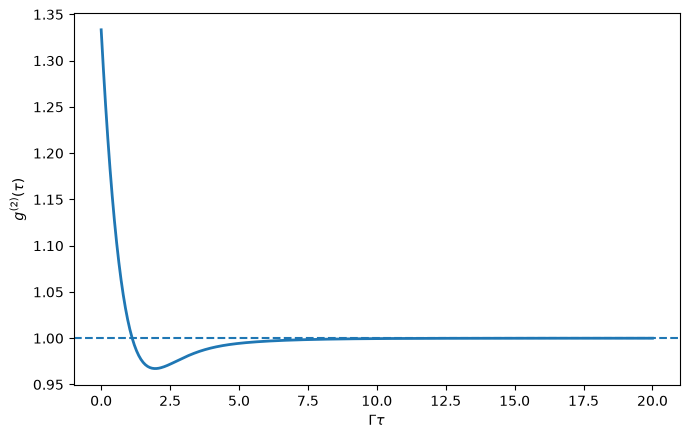

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *


# ============================================================
# 1. Basic three-atom operators
# ============================================================

N = 3


def op_on_atom(op, j):
    """
    Put single-atom operator 'op' on atom j.
    """
    ops = [qeye(2) for _ in range(N)]
    ops[j] = op
    return tensor(ops)


sm = [op_on_atom(sigmam(), j) for j in range(N)]
sp = [op_on_atom(sigmap(), j) for j in range(N)]
sz = [op_on_atom(sigmaz(), j) for j in range(N)]


# ============================================================
# 2. Geometry: equilateral triangle in xy plane
# ============================================================

def triangle_positions(a):
    """
    Equilateral triangle of side a, centered at origin.
    """
    r1 = np.array([0.0, a / np.sqrt(3.0), 0.0])
    r2 = np.array([-a / 2.0, -a / (2.0 * np.sqrt(3.0)), 0.0])
    r3 = np.array([+a / 2.0, -a / (2.0 * np.sqrt(3.0)), 0.0])

    return np.array([r1, r2, r3])


# ============================================================
# 3. Free-space collective decay and dipole-dipole shift
# ============================================================

def gamma_perpendicular(r, k0, Gamma):
    """
    Collective decay Gamma_ij when dipole is perpendicular
    to the interatomic separation.
    """
    x = k0 * r

    return (3.0 * Gamma / 2.0) * (
        np.sin(x) / x
        + np.cos(x) / x**2
        - np.sin(x) / x**3
    )


def omega_perpendicular(r, k0, Gamma):
    """
    Resonant dipole-dipole coupling Omega_ij when dipole is
    perpendicular to interatomic separation.
    """
    x = k0 * r

    return -(3.0 * Gamma / 4.0) * (
        np.cos(x) / x
        - np.sin(x) / x**2
        - np.cos(x) / x**3
    )


def coupling_matrices(positions, k0, Gamma):
    """
    Construct Gamma_ij and Omega_ij matrices.
    """
    Gamma_mat = np.zeros((N, N), dtype=float)
    Omega_mat = np.zeros((N, N), dtype=float)

    for i in range(N):
        Gamma_mat[i, i] = Gamma

        for j in range(i + 1, N):
            rij = np.linalg.norm(positions[i] - positions[j])

            gij = gamma_perpendicular(rij, k0, Gamma)
            oij = omega_perpendicular(rij, k0, Gamma)

            Gamma_mat[i, j] = gij
            Gamma_mat[j, i] = gij

            Omega_mat[i, j] = oij
            Omega_mat[j, i] = oij

    return Gamma_mat, Omega_mat


# ============================================================
# 4. Collapse operators from collective decay matrix
# ============================================================

def collective_collapse_operators(Gamma_mat, nbar=0.0):
    """
    Construct collective emission and absorption collapse operators.

    Thermal master equation:

      Gamma_ij (nbar+1) : emission
      Gamma_ij nbar     : absorption

    We diagonalize Gamma_ij to obtain independent Lindblad channels.
    """

    eigenvalues, eigenvectors = np.linalg.eigh(Gamma_mat)

    c_ops = []

    for alpha, lam in enumerate(eigenvalues):

        # Remove numerical negative eigenvalues ~ -1e-15
        if lam < 0.0 and abs(lam) < 1e-12:
            lam = 0.0

        if lam < 0.0:
            raise ValueError(
                f"Decay matrix is not positive semidefinite: "
                f"eigenvalue = {lam}"
            )

        if lam < 1e-14:
            continue

        # Collective lowering operator
        Lminus = 0 * sm[0]

        for j in range(N):
            Lminus += eigenvectors[j, alpha] * sm[j]

        # Emission
        c_ops.append(
            np.sqrt((nbar + 1.0) * lam) * Lminus
        )

        # Thermal absorption
        if nbar > 0.0:
            c_ops.append(
                np.sqrt(nbar * lam) * Lminus.dag()
            )

    return c_ops


# ============================================================
# 5. Hamiltonian
# ============================================================

def make_hamiltonian(
    Omega_mat,
    detuning=0.0,
    Omega_drive=0.0
):
    """
    Rotating-frame Hamiltonian.

    detuning:
        atom-laser detuning

    Omega_drive:
        resonant Rabi frequency

    Omega_drive = 0 gives purely thermal fluorescence.
    """

    H = 0 * sz[0]

    # Atomic detuning
    for j in range(N):
        H += 0.5 * detuning * sz[j]

    # Coherent laser driving
    for j in range(N):
        H += 0.5 * Omega_drive * (sp[j] + sm[j])

    # Dipole-dipole interaction
    for i in range(N):
        for j in range(i + 1, N):

            H += Omega_mat[i, j] * (
                sp[i] * sm[j]
                + sp[j] * sm[i]
            )

    return H


# ============================================================
# 6. Far-field detector operator
# ============================================================

def detector_operator(
    positions,
    k0,
    theta=np.pi / 2,
    phi=0.0
):
    """
    Far-field positive-frequency detector operator

        J(n) = sum_j exp[-i k n.r_j] sigma_j^-

    theta is measured from the z-axis.
    phi is the azimuthal angle.

    Dipoles are along z.

    theta = pi/2 corresponds to detection in the xy plane,
    where z-oriented dipoles radiate maximally.
    """

    nhat = np.array([
        np.sin(theta) * np.cos(phi),
        np.sin(theta) * np.sin(phi),
        np.cos(theta)
    ])

    J = 0 * sm[0]

    for j in range(N):

        phase = np.exp(
            -1j * k0 * np.dot(nhat, positions[j])
        )

        J += phase * sm[j]

    return J


# ============================================================
# 7. g^(2)(tau)
# ============================================================

def calculate_g2(
    H,
    c_ops,
    J1,
    J2,
    taus
):
    """
    Stationary two-time second-order correlation:

      g2(tau) =
      <J1^dag(0) J2^dag(tau) J2(tau) J1(0)>
      ------------------------------------------------
                 <J1^dag J1><J2^dag J2>

    We calculate this by conditional evolution after a
    detection by J1.
    """

    # Steady state
    rho_ss = steadystate(H, c_ops)

    # Detector intensities
    I1_op = J1.dag() * J1
    I2_op = J2.dag() * J2

    I1 = np.real((I1_op * rho_ss).tr())
    I2 = np.real((I2_op * rho_ss).tr())

    if I1 < 1e-14 or I2 < 1e-14:
        raise ValueError(
            "Steady-state detector intensity is zero. "
            "Use finite thermal pumping or coherent driving."
        )

    # --------------------------------------------------------
    # State immediately after the first photon detection
    #
    # rho_c(0) = J1 rho_ss J1^dag / I1
    # --------------------------------------------------------

    rho_c0 = J1 * rho_ss * J1.dag()
    rho_c0 = rho_c0 / I1

    # Evolve conditional state
    result = mesolve(
        H,
        rho_c0,
        taus,
        c_ops,
        e_ops=[I2_op]
    )

    I_cond = np.real(np.asarray(result.expect[0]))

    # Since rho_c0 was normalized by I1,
    #
    # g2(tau) = I2_cond(tau) / I2
    #
    g2 = I_cond / I2

    return g2, rho_ss, I1, I2


# ============================================================
# 8. Parameters
# ============================================================

Gamma = 1.0

# Use wavelength as length unit
lambda0 = 1.0
k0 = 2.0 * np.pi / lambda0

# Triangle side length
a = 0.25 * lambda0

positions = triangle_positions(a)

# Thermal photon occupation
nbar = 0.10

# No coherent drive for thermal fluorescence
Omega_drive = 0.0
detuning = 0.0


# ============================================================
# 9. Construct collective couplings
# ============================================================

Gamma_mat, Omega_mat = coupling_matrices(
    positions,
    k0,
    Gamma
)

print("Gamma matrix:")
print(Gamma_mat)

print("\nOmega matrix:")
print(Omega_mat)

print("\nEigenvalues of Gamma matrix:")
print(np.linalg.eigvalsh(Gamma_mat))


# ============================================================
# 10. Master equation
# ============================================================

c_ops = collective_collapse_operators(
    Gamma_mat,
    nbar=nbar
)

H = make_hamiltonian(
    Omega_mat,
    detuning=detuning,
    Omega_drive=Omega_drive
)


# ============================================================
# 11. Detector directions
# ============================================================

# Detector 1:
# theta = pi/2 -> detector in plane of triangle
# phi = 0     -> +x direction

theta1 = np.pi / 2
phi1 = 0.0

J1 = detector_operator(
    positions,
    k0,
    theta=theta1,
    phi=phi1
)

# For ordinary autocorrelation use same detector mode:
J2 = J1

# To calculate correlation between two different directions,
# for example, replace J2 by:
#
# J2 = detector_operator(
#     positions,
#     k0,
#     theta=np.pi/2,
#     phi=np.pi/2
# )


# ============================================================
# 12. Calculate g^(2)(tau)
# ============================================================

taus = np.linspace(0.0, 20.0 / Gamma, 500)

g2, rho_ss, I1, I2 = calculate_g2(
    H,
    c_ops,
    J1,
    J2,
    taus
)

print("\nDetector intensity =", I1)
print("g2(0) =", g2[0])
print("g2(infinity) approximately =", g2[-1])


# ============================================================
# 13. Plot
# ============================================================

plt.figure(figsize=(7, 4.5))

plt.plot(Gamma * taus, g2, lw=2)
plt.axhline(1.0, ls="--")

plt.xlabel(r"$\Gamma\tau$")
plt.ylabel(r"$g^{(2)}(\tau)$")

plt.tight_layout()
plt.show()

In [ ]:
result = qt.mcsolve(H, psi0, tlist, c_ops, ...)